# Hierarchical Adaptive FIR — first experiment

This notebook tests the idea in stages:

1. A synthetic regime-switching process where the true dynamics are known.
2. Fixed FIR vs adaptive FIR vs meta-adaptive FIR.
3. Strict sequential / walk-forward evaluation.
4. Optional S&P 500 daily data from FRED.
5. Diagnostic plots of predictions, errors, FIR weights and learning rate.

The first version deliberately keeps the hierarchy simple. The next experiment can add a third level where the rate of change of the learning rate adapts too.

## Data source

For the real-data experiment we use the FRED `SP500` series. FRED describes it as the S&P 500 daily closing index, sourced from S&P Dow Jones Indices LLC. The series is a **price index**, not a total-return index.

FRED currently provides a limited daily-history window, so the notebook also accepts a local CSV. If you have a longer historical file, put it at `data/sp500.csv` with columns containing a date and close value.

Source: https://fred.stlouisfed.org/series/SP500

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


In [2]:
def make_lag_matrix(returns, n_lags):
    returns = np.asarray(returns, dtype=float)

    X = np.empty((len(returns) - n_lags, n_lags))
    y = np.empty(len(returns) - n_lags)

    for i in range(n_lags, len(returns)):
        X[i - n_lags] = returns[i-n_lags:i][::-1]
        y[i - n_lags] = returns[i]

    return X, y


def evaluate(actual, prediction):
    mask = np.isfinite(actual) & np.isfinite(prediction)

    y = np.asarray(actual)[mask]
    p = np.asarray(prediction)[mask]
    e = y - p

    mse = np.mean(e**2)
    mae = np.mean(np.abs(e))

    correlation = (
        np.corrcoef(y, p)[0, 1]
        if np.std(p) > 0 and np.std(y) > 0
        else np.nan
    )

    directional_accuracy = np.mean(
        np.sign(y) == np.sign(p)
    )

    return pd.Series({
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mae,
        "Prediction correlation": correlation,
        "Directional accuracy": directional_accuracy,
        "N": len(y)
    })


## 1. Synthetic regime-switching market

We deliberately create a process whose autoregressive coefficient changes. This lets us ask whether the adaptive filter actually reacts when the underlying process changes.

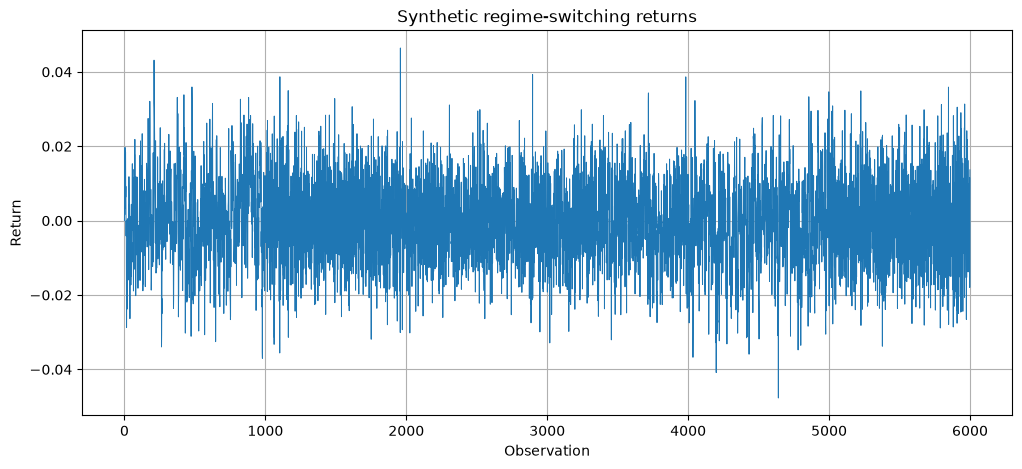

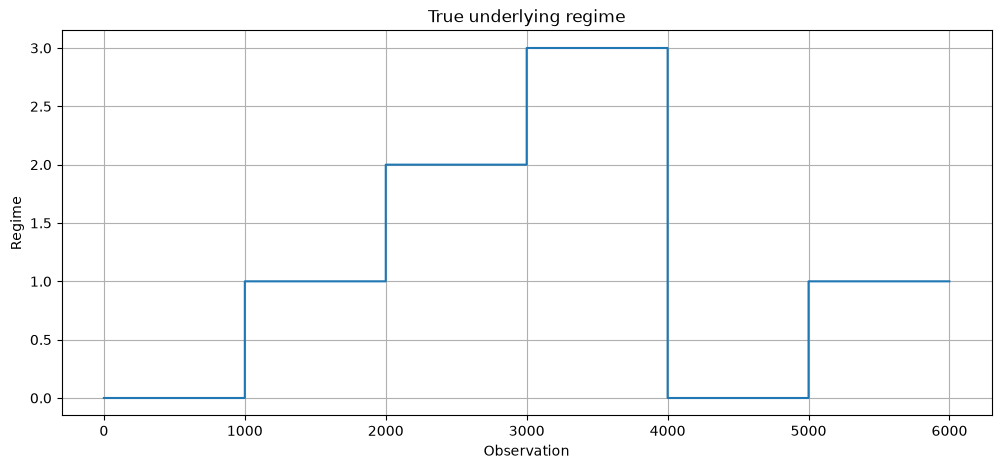

In [3]:
def synthetic_regime_market(
    n=6000,
    regime_length=1000,
    phi_values=(0.6, -0.5, 0.0, 0.35),
    noise_std=0.01
):
    r = np.zeros(n)
    regime = np.zeros(n, dtype=int)

    for t in range(1, n):
        regime[t] = (t // regime_length) % len(phi_values)
        phi = phi_values[regime[t]]

        r[t] = phi * r[t-1] + np.random.normal(
            0.0, noise_std
        )

    return r, regime


synthetic_returns, synthetic_regime = synthetic_regime_market()

plt.figure()
plt.plot(synthetic_returns, linewidth=0.7)
plt.title("Synthetic regime-switching returns")
plt.xlabel("Observation")
plt.ylabel("Return")
plt.show()

plt.figure()
plt.step(
    np.arange(len(synthetic_regime)),
    synthetic_regime,
    where="post"
)
plt.title("True underlying regime")
plt.xlabel("Observation")
plt.ylabel("Regime")
plt.show()


## 2. Fixed FIR baseline

In [4]:
class FixedFIR:
    def __init__(self, n_lags):
        self.n_lags = n_lags
        self.weights = np.zeros(n_lags)

    def fit(self, returns):
        X, y = make_lag_matrix(returns, self.n_lags)
        self.weights = np.linalg.lstsq(X, y, rcond=None)[0]

    def predict(self, x):
        return float(np.dot(self.weights, x))


## 3. Ordinary adaptive FIR

This is the LMS-style model. The weights change after every new observation.

In [5]:
class AdaptiveFIR:
    def __init__(
        self,
        n_lags,
        learning_rate=0.01
    ):
        self.n_lags = n_lags
        self.learning_rate = learning_rate
        self.weights = np.zeros(n_lags)

    def predict(self, x):
        return float(np.dot(self.weights, x))

    def update(self, x, actual):
        prediction = self.predict(x)
        error = actual - prediction

        self.weights += (
            self.learning_rate * error * x
        )

        return {
            "prediction": prediction,
            "error": error,
            "learning_rate": self.learning_rate,
            "weights": self.weights.copy()
        }


## 4. Meta-adaptive FIR

Here the FIR weights adapt, but the learning rate adapts as well. The learning rate increases when smoothed prediction error is rising and decreases when it is falling.

This is deliberately a simple first implementation; it is a baseline for the more interesting recursive hierarchy.

In [6]:
class MetaAdaptiveFIR:
    def __init__(
        self,
        n_lags,
        learning_rate=0.01,
        meta_rate=0.001,
        error_smoothing=0.05,
        min_learning_rate=1e-5,
        max_learning_rate=0.1
    ):
        self.n_lags = n_lags

        self.learning_rate = learning_rate
        self.meta_rate = meta_rate
        self.error_smoothing = error_smoothing

        self.min_learning_rate = min_learning_rate
        self.max_learning_rate = max_learning_rate

        self.weights = np.zeros(n_lags)

        self.error_energy = 0.0
        self.previous_error_energy = 0.0

    def predict(self, x):
        return float(np.dot(self.weights, x))

    def update(self, x, actual):
        prediction = self.predict(x)
        error = actual - prediction

        self.previous_error_energy = self.error_energy

        self.error_energy = (
            (1 - self.error_smoothing)
            * self.error_energy
            + self.error_smoothing * error**2
        )

        error_trend = (
            self.error_energy
            - self.previous_error_energy
        )

        self.learning_rate += (
            self.meta_rate * error_trend
        )

        self.learning_rate = np.clip(
            self.learning_rate,
            self.min_learning_rate,
            self.max_learning_rate
        )

        self.weights += (
            self.learning_rate * error * x
        )

        return {
            "prediction": prediction,
            "error": error,
            "learning_rate": self.learning_rate,
            "error_energy": self.error_energy,
            "weights": self.weights.copy()
        }


## 5. Strict sequential evaluation

There is deliberately no batch fitting here. At each point the model sees only information that would have been available immediately before that prediction.

In [7]:
def run_adaptive_filter(returns, model):
    returns = np.asarray(returns, dtype=float)

    n = len(returns)

    predictions = np.full(n, np.nan)
    errors = np.full(n, np.nan)
    learning_rates = np.full(n, np.nan)
    error_energy = np.full(n, np.nan)

    weight_history = np.full(
        (n, model.n_lags),
        np.nan
    )

    for t in range(model.n_lags, n):
        x = returns[t-model.n_lags:t][::-1]

        result = model.update(
            x,
            returns[t]
        )

        predictions[t] = result["prediction"]
        errors[t] = result["error"]
        learning_rates[t] = result.get(
            "learning_rate", np.nan
        )
        error_energy[t] = result.get(
            "error_energy", np.nan
        )
        weight_history[t] = result["weights"]

    return {
        "predictions": predictions,
        "errors": errors,
        "learning_rates": learning_rates,
        "error_energy": error_energy,
        "weights": weight_history
    }


## 6. Run the three models on synthetic data

In [8]:
N_LAGS = 20

# Fixed FIR
fixed = FixedFIR(N_LAGS)

# To avoid look-ahead in the comparison, estimate the fixed
# model only on the first half and evaluate on the second half.
split = len(synthetic_returns) // 2

fixed.fit(synthetic_returns[:split])

fixed_predictions = np.full(
    len(synthetic_returns),
    np.nan
)

for t in range(max(N_LAGS, split), len(synthetic_returns)):
    x = synthetic_returns[t-N_LAGS:t][::-1]
    fixed_predictions[t] = fixed.predict(x)


# Adaptive FIR
adaptive = AdaptiveFIR(
    N_LAGS,
    learning_rate=0.05
)

adaptive_result = run_adaptive_filter(
    synthetic_returns,
    adaptive
)


# Meta-adaptive FIR
meta = MetaAdaptiveFIR(
    N_LAGS,
    learning_rate=0.01,
    meta_rate=0.5,
    error_smoothing=0.02,
    min_learning_rate=1e-5,
    max_learning_rate=0.1
)

meta_result = run_adaptive_filter(
    synthetic_returns,
    meta
)


results = pd.DataFrame({
    "Fixed FIR": evaluate(
        synthetic_returns[split:],
        fixed_predictions[split:]
    ),
    "Adaptive FIR": evaluate(
        synthetic_returns,
        adaptive_result["predictions"]
    ),
    "Meta-adaptive FIR": evaluate(
        synthetic_returns,
        meta_result["predictions"]
    )
}).T

results


,MSE,RMSE,MAE,Prediction correlation,Directional accuracy,N
Fixed FIR,0.000130,0.011385,0.009059,0.226340,0.571000,3000.0
Adaptive FIR,0.000131,0.011431,0.009073,0.172986,0.539632,5980.0
Meta-adaptive FIR,0.000131,0.011442,0.009081,0.172063,0.539298,5980.0


## 7. Inspect the meta-adaptive behaviour

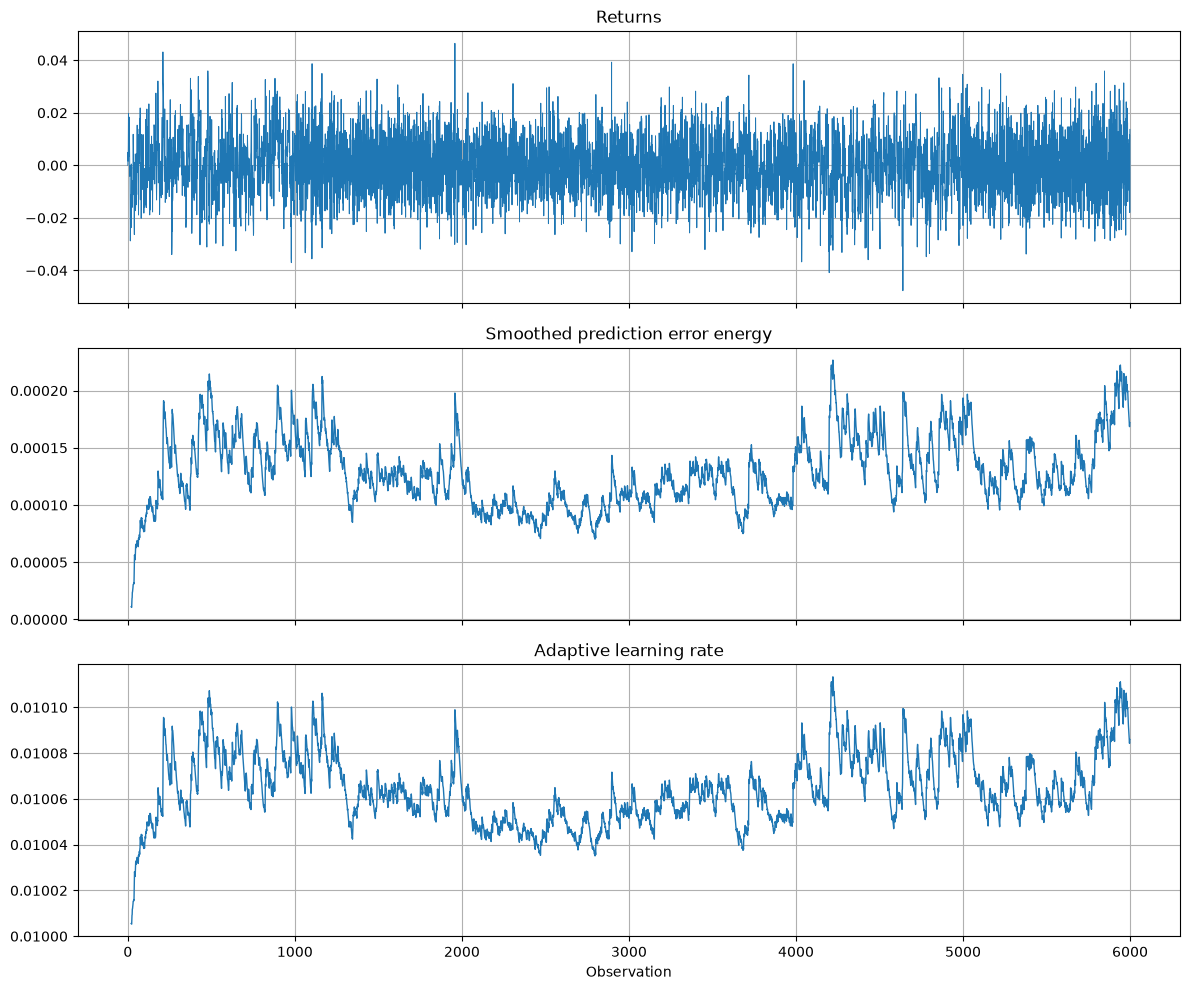

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

ax[0].plot(synthetic_returns, linewidth=0.7)
ax[0].set_title("Returns")

ax[1].plot(
    meta_result["error_energy"],
    linewidth=1
)
ax[1].set_title("Smoothed prediction error energy")

ax[2].plot(
    meta_result["learning_rates"],
    linewidth=1
)
ax[2].set_title("Adaptive learning rate")
ax[2].set_xlabel("Observation")

plt.tight_layout()
plt.show()


## 8. Inspect the FIR weights

A useful diagnostic is to see whether the adaptive filter changes its effective temporal structure when the regime changes.

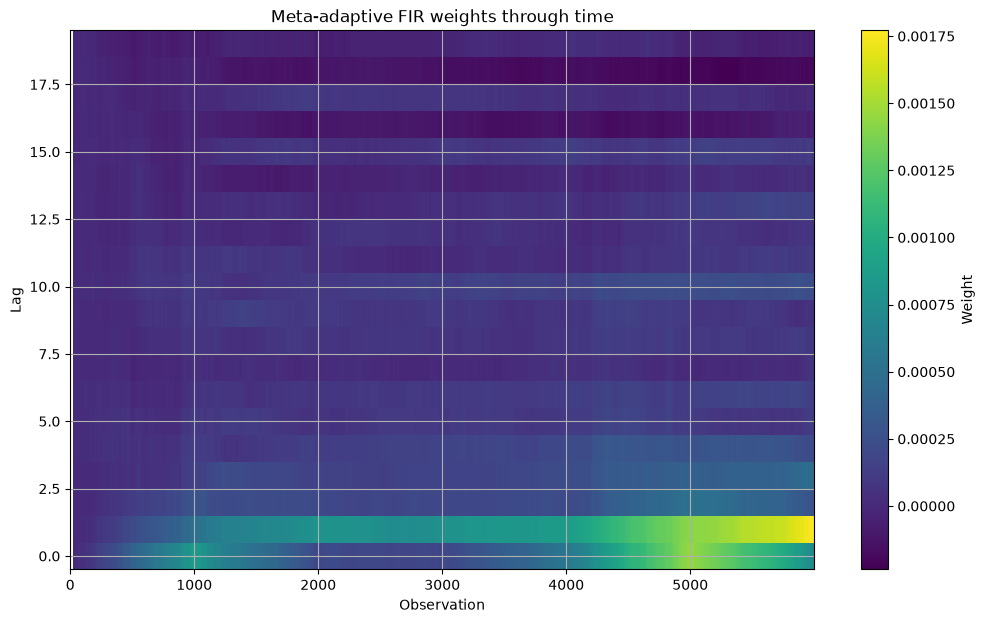

In [10]:
weights = meta_result["weights"]

plt.figure(figsize=(12, 7))

plt.imshow(
    weights.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

plt.colorbar(label="Weight")
plt.title("Meta-adaptive FIR weights through time")
plt.xlabel("Observation")
plt.ylabel("Lag")
plt.show()


## 9. Optional: load S&P 500 data

FRED's `SP500` series can be read directly using its CSV endpoint. For a longer historical experiment, replace this with a local CSV containing the historical series.

In [11]:
FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500"

try:
    spx = pd.read_csv(
        FRED_URL,
        parse_dates=["observation_date"]
    )

    spx = spx.rename(
        columns={
            "observation_date": "date",
            "SP500": "close"
        }
    )

    spx["close"] = pd.to_numeric(
        spx["close"],
        errors="coerce"
    )

    spx = (
        spx
        .dropna(subset=["close"])
        .sort_values("date")
        .reset_index(drop=True)
    )

    spx["return"] = np.log(
        spx["close"]
        / spx["close"].shift(1)
    )

    spx = spx.dropna().reset_index(drop=True)

    print(
        f"Loaded {len(spx):,} daily observations "
        f"from {spx.date.min().date()} "
        f"to {spx.date.max().date()}."
    )

    display(spx.tail())

except Exception as exc:
    print("Could not download FRED data:", exc)
    print("Use a local CSV instead.")


Loaded 2,511 daily observations from 2016-08-22 to 2026-08-18.


,date,close,return
2506,2026-08-12,7748.50,0.002623
2507,2026-08-13,7798.99,0.006495
2508,2026-08-14,7785.76,-0.001698
2509,2026-08-17,7745.06,-0.005241
2510,2026-08-18,7691.76,-0.006906


## 10. Run the meta-adaptive filter on S&P 500 returns

In [12]:
if "spx" in globals():

    spx_returns = spx["return"].to_numpy()

    spx_model = MetaAdaptiveFIR(
        n_lags=50,
        learning_rate=0.01,
        meta_rate=0.5,
        error_smoothing=0.02,
        min_learning_rate=1e-5,
        max_learning_rate=0.1
    )

    spx_result = run_adaptive_filter(
        spx_returns,
        spx_model
    )

    spx_metrics = evaluate(
        spx_returns,
        spx_result["predictions"]
    )

    display(spx_metrics)


MSE                          0.000133
RMSE                         0.011512
MAE                          0.007408
Prediction correlation       0.106773
Directional accuracy         0.509955
N                         2461.000000
dtype: float64

## 11. S&P 500 diagnostics

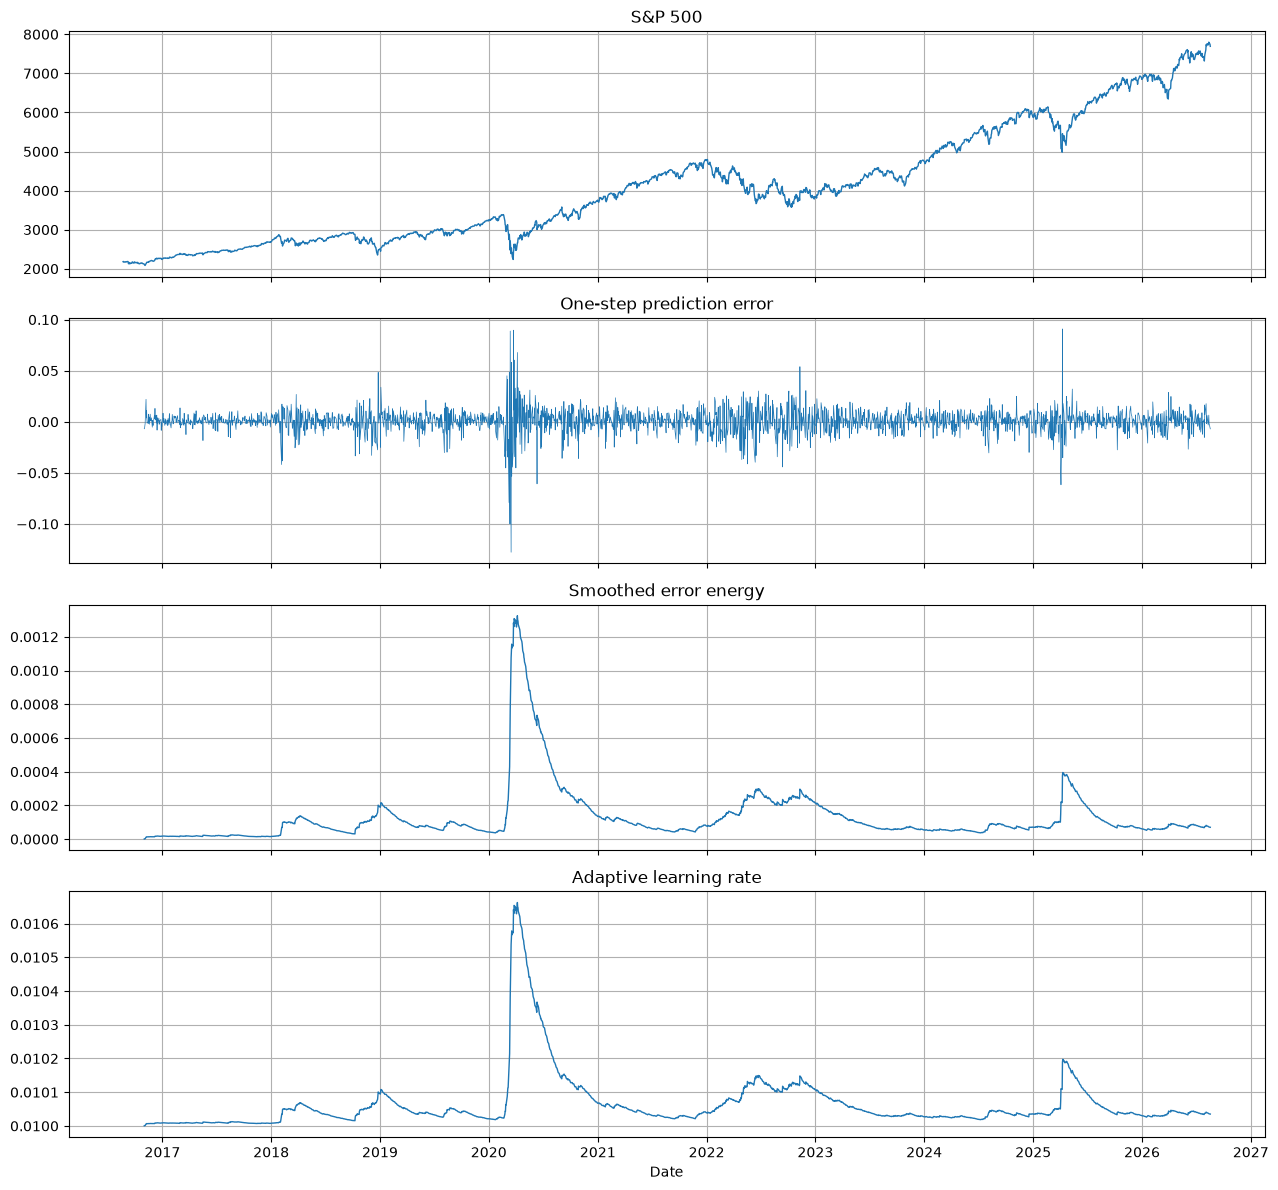

In [13]:
if "spx" in globals():

    dates = spx["date"]

    fig, ax = plt.subplots(
        4, 1,
        figsize=(13, 12),
        sharex=True
    )

    ax[0].plot(
        dates,
        spx["close"],
        linewidth=1
    )
    ax[0].set_title("S&P 500")

    ax[1].plot(
        dates,
        spx_result["errors"],
        linewidth=0.5
    )
    ax[1].set_title("One-step prediction error")

    ax[2].plot(
        dates,
        spx_result["error_energy"],
        linewidth=1
    )
    ax[2].set_title("Smoothed error energy")

    ax[3].plot(
        dates,
        spx_result["learning_rates"],
        linewidth=1
    )
    ax[3].set_title("Adaptive learning rate")
    ax[3].set_xlabel("Date")

    plt.tight_layout()
    plt.show()


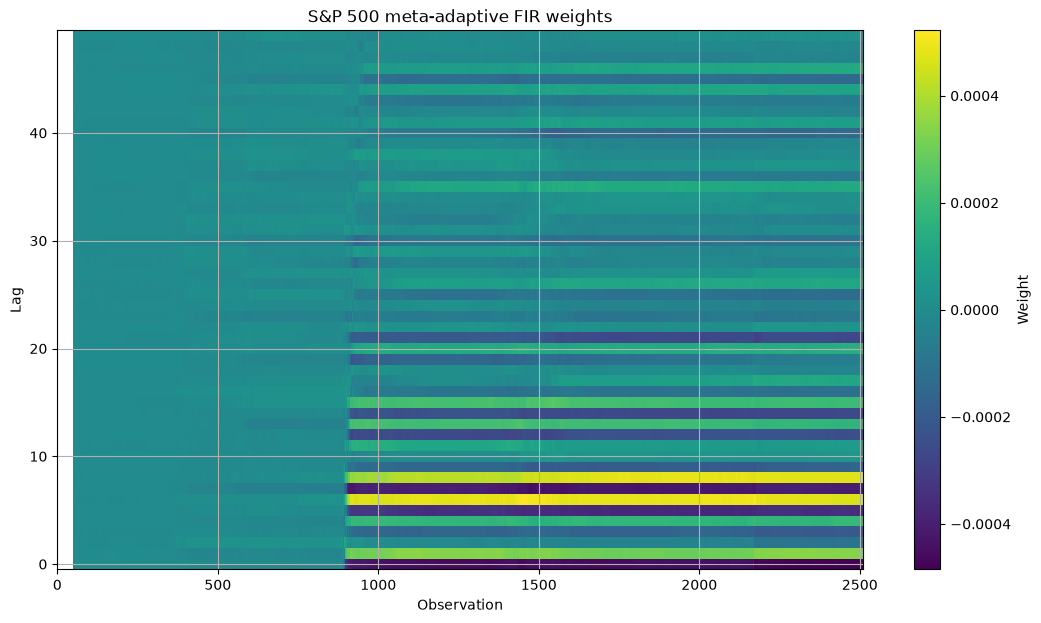

In [14]:
if "spx" in globals():

    plt.figure(figsize=(13, 7))

    plt.imshow(
        spx_result["weights"].T,
        aspect="auto",
        origin="lower",
        interpolation="nearest"
    )

    plt.colorbar(label="Weight")
    plt.title("S&P 500 meta-adaptive FIR weights")
    plt.xlabel("Observation")
    plt.ylabel("Lag")
    plt.show()


## 12. Next experiment: the third level

The next version should add a second adaptive state:

\[
w_t \leftarrow \mu_t \leftarrow \alpha_t
\]

where the FIR weights adapt according to `mu`, and `mu` itself changes according to `alpha`.

The important thing is to resist adding arbitrary parameters. We should make the third level as self-similar as possible and then test whether it improves **out-of-sample** prediction over the two-level model.

After that, we should test the same hierarchy on a synthetic process where the *rate of regime change* itself changes. That is the experiment most directly connected to the original idea of "adaptation of the adaptation of the adaptation." 